# Preliminaries

In [77]:
from dolfin import *
from ufl import indices, Jacobian, Min, Max, And, shape
import numpy as np
import os, pygmsh, gmsh, meshio

In [78]:
# plotting customizations
from matplotlib import pyplot as plt
from matplotlib import tri, colormaps, colors, cm
from mpl_toolkits.mplot3d import axes3d
size=18
params = {'legend.fontsize': size*0.75,
        #   'figure.figsize': (20,8),
          'text.usetex': True,
          'text.latex.preamble': r'\usepackage{mathrsfs,bm}',
        #   'mathtext.fontset': 'stix',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25,
          'animation.embed_limit': 2**128}
plt.rcParams.update(params)
%matplotlib inline

## Credit

Based heavily on [fitted-fsi-example](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master/fsi) from David Kamensky's [MAE 207: FEA for coupled problems](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master) course at UC San Diego.

Initial version written by U. Rade, Purdue University, for the simulations in the paper "Theory and simulation of elastoinertial rectification of oscillatory flows in two-dimensional deformable rectangular channels" (preprint [arXiv:2505.22799](https://arxiv.org/abs/2505.22799)).

Next rewrite by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University (with input from Copilot) includes:
- converting to notebook format for easier on-the-fly analysis, 
- complete reorganization of simulation and model parameter initialization,
- switching to gmsh for modern meshing,
- implementing Carreau viscosity model for fluid,
- implementing 2D restriction of neo-Hookean solid,
- implementing velocity-based damping in the solid for improved convergence to steady state,
- adding steady analytical solution comparisons,
- various other small improvements.

If you want to run this solver as a standalone python script (stripping all Markdown comments, etc), run the following command in your terminal:

`
jupyter nbconvert new_ALE-FSI_2D.ipynb --to python --PythonExporter.exclude_markdown=True
`

which creates the file `new_ALE-FSI_2D.py`.

## Introduction

Sketch of the geometry and notation.

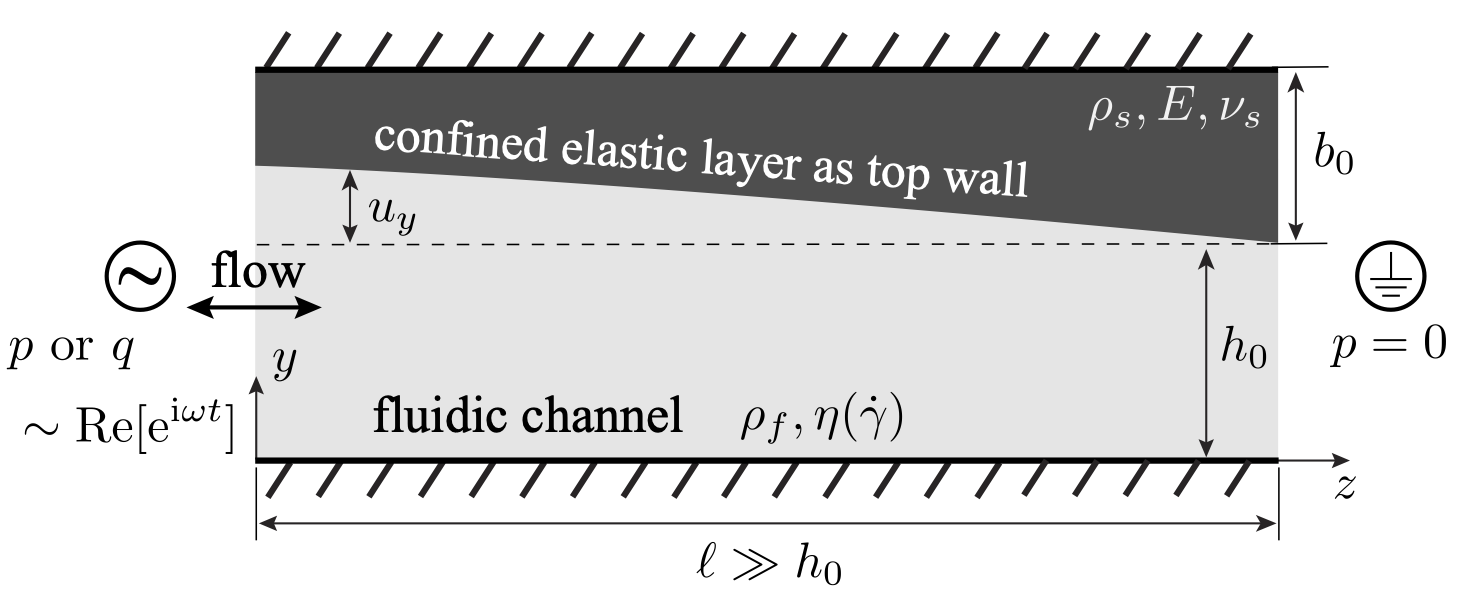

<span style="color: red">WARNING:</span> Carreau model is only implemented in the numerics. The theory relies on the power-law approximation &amp; Winkler-foundation elastic model.

# Problem setup

## General simulation settings

### Data storage

In [79]:
# If the folder does not exist, create it.
# I'm using a folder that will not get synced to GitHub.
DataFolder = "not-ready-for-github/simulation_output/"
if not os.path.exists(DataFolder):
    os.makedirs(DataFolder)
    print(f"CREATED data storage folder: {DataFolder}")
else:
    print(f"Using EXISTING data storage folder: {DataFolder}")

Using EXISTING data storage folder: not-ready-for-github/simulation_output/


### Algorithmic settings

Shouldn't require changing.

In [80]:
LSIC            = False     # Least-squares incompressibility stabilization for fluid
BACKFLOW_STAB   = True      # Backflow stabilization for fluid
SUPG            = False     # Streamline Upwind Petrov-Galerkin stabilization for fluid
                            # shouldn't needed for low Re flow or with Taylor-Hood elements

print("============================ INFO ============================")
print(f"SUPG stabilization:       {'ON' if SUPG else 'OFF'}")
print(f"LSIC stabilization:       {'ON' if LSIC else 'OFF'}")
print(f"Backflow stabilization:   {'ON' if BACKFLOW_STAB else 'OFF'}")
print("=============================================================")

============================ INFO ============================
SUPG stabilization:       OFF
LSIC stabilization:       OFF
Backflow stabilization:   ON


## General problem settings

### Parameters defining domain geometry

In [81]:
b0 = 0.01
h0 = b0
l  = 50*h0
# Solid domain extents:
SOLID_TOP    = h0+b0
SOLID_BOTTOM = h0
SOLID_LEFT   = 0.0
SOLID_RIGHT  = l
# Combined domain size:
OMEGA_H      = h0+b0
OMEGA_W      = l
# Flags for subdomains:
FLUID_FLAG   = 0
SOLID_FLAG   = 1
# Desired resolution of mesh:
N = 100 # 600
# Refine near inlet in SOLID domain only
inlet_refinement_solid_only = True
inlet_refinement = 0.33 # 1 = no refinement, 1/() times finer
# Refinement near fluid-solid interface
interface_refinement = 0.33 # 1 = no refinement, 1/() times finer
# Geometry-scale tolerance for subdomains:
d_tol = h0 * 1e-8

### Material properties (dimensional)

The solid is linearly elastic (with material constants $E_s$, $\nu_s$).

The fluid is a generalized Newtonian fluid with shear-thinning behavior described by the Carreau model:
\begin{align*}
     \eta(\dot{\gamma}) 
     &= \eta_{\infty} + \left(\eta_0-\eta_{\infty}\right) \left[ 1 + (\lambda \dot{\gamma})^2 \right]^{(n-1)/2} \\
     &= \eta_{0} \left\{ \beta + (1-\beta) \left[ 1 + (\lambda \dot{\gamma})^2 \right]^{(n-1)/2} \right\} \\
     &= \eta_{0} \left\{ \beta + (1-\beta) |\lambda \dot{\gamma}|^{n-1} \right\}, \qquad |\lambda \dot{\gamma}| \gg 1 \\
     &= \eta_{0} |\lambda \dot{\gamma}|^{n-1}\qquad\qquad\;\;\; \beta \ll 1,\quad |\lambda \dot{\gamma}| \gg 1.
\end{align*}

In [82]:
# Elasticity model for real solid:
ELASTICITY_MODEL = "NEOH"  # "STVK" for St. Venant--Kirchhoff 
                           # "NEOH" for neo-Hookean, more robust than STVK

# Elastic solid's properties:
E_s    = 3e+5                           # Young's modulus
nu_s   = 0.45                           # Poisson ratio
mu_s   = Constant(E_s/(2*(1+nu_s)))     # Shear modulus
K      = Constant(E_s/(3*(1-2*nu_s)))   # Bulk modulus
rho_s0 = Constant(1e3)                  # Solid's density if ref. config.
cs     = sqrt(mu_s/rho_s0)              # Shear wave speed in solid
#print("Shear wave speed in solid is", f"{float(cs):.4g}")   # .4g = 4 sig figs
zeta   = 0.10
cd_est = 2.0 * zeta * float(cs / b0)
print(f"Try damping coeff ~ {cd_est:.3g} 1/s for damping factor = {zeta:.3g}")
cd     = Constant(1.0*cd_est)           # Velocity-based damping coefficient 
                                        # (to suppresses transients for steady simulations)

# Viscous fluid properties to yield desired dimensionless numbers,
# based on dynamic similarity:
rho_f     = Constant(1e1)               # Fluid's density
eta_f_0   = Constant(10.0)              # Zero-shear viscosity ~ 0.1
eta_f_inf = Constant(0.0)               # Inf-shear viscosity, ~0.01 or 0.0001
n         = Constant(1.0)               # Shear-thinning/plaw index, ~0.5
lam_r     = Constant(0.0)               # Char. shear rate for thinning, ~10.0
# Consistency index for power-law approximation:
m_plaw    = eta_f_0*lam_r**(n-1) 

Try damping coeff ~ 203 1/s for damping factor = 0.1


### Dimensionless numbers

To determine the scales and dimensionless numbers we need to pick the BC type here.

In [83]:
FLOW_OR_PRESSURE = "PRESSURE"    # "FLOW" or "PRESSURE"

p_amp = Constant(2e5)            # Pressure amplitude
q_amp = Constant(0.1)            # Flow rate amplitude

In [84]:
# Adjust scales for either flow rate or pressure control BC:
if FLOW_OR_PRESSURE == "FLOW":
    q_c = q_amp
    v_c = q_c/h0
    p_c = eta_f_0*q_c*l/h0**3
    dp_rigid = 12.0*float(p_c)
    q_rigid = float(q_c)    
elif FLOW_OR_PRESSURE == "PRESSURE":
    p_c = p_amp
    q_c = (p_c/l)*(h0**3/eta_f_0)
    v_c = q_c/h0
    dp_rigid = float(p_c)
    q_rigid = float(q_c/12.0)    
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

In [85]:
omega = 0                                                    # Frequency (for oscillatory flow)

epsilon_f = h0/l                                             # Fluid (inverse) aspect ratio
epsilon_s = b0/l                                             # Solid (inverse) aspect ratio

C_I = 2*nu_s*(nu_s-1/4)/(3*(1-nu_s)**2)*(b0**3/mu_s/l**2)    # Incompressible foundation compliance
C_w = (1-2*nu_s)/(2*(1-nu_s))*(b0/mu_s)                      # Winkler foundation compliance
C_H = (nu_s-1/4)/(1-nu_s)*(b0**2/mu_s/l)                     # Horizontal component compliance
theta = float(C_I/C_w)
vartheta = float(C_H/C_w)
alpha = float(p_c/(h0/C_w))                                  # Compliance number

Wo = sqrt(h0**2 * omega/float(eta_f_0/rho_f))                # Womersley number

gamma = float(C_w*l*eta_f_0*omega/(epsilon_f*h0**2))         # Elastoviscous number

#Re = float(rho_f * epsilon_f**2 * h0**2 * p_c/eta_f**2)     # Reynolds number
Re = float(epsilon_f * rho_f * v_c * h0/eta_f_0) 
#Re = float(Wo**2 * alpha/gamma)                             # Only if unsteady

beta = float(eta_f_inf/eta_f_0)                              # Carreau viscosity ratio
Cu = float(lam_r * v_c/h0)                                   # Carreau number

print("============================ INFO ===========================")
print(f">>> Using {FLOW_OR_PRESSURE}-controlled BC & appropriate scales.")
print("-------------------------------------------------------------")
print(f"ε_f = {epsilon_f:.5f}")
print(f"ε_s = {epsilon_s:.5f}")
print(f"θ   = {theta:.5f}")
print(f"α   = {alpha:.5f} (compliance #)")
print(f"Wo  = {Wo:.5f} (Womersley #)")
print(f"γ   = {gamma:.5f} (Elastoviscous #)")
print(f"εRe = {Re:.5f} (Reynolds #)")
print(f"β   = {beta:.5f} (viscosity ratio)")
print(f"Cu  = {Cu:.5f} (Carreau #)")
print("=============================================================")

============================ INFO ===========================
>>> Using PRESSURE-controlled BC & appropriate scales.
-------------------------------------------------------------
ε_f = 0.02000
ε_s = 0.02000
θ   = 0.00087
α   = 0.17576 (compliance #)
Wo  = 0.00000 (Womersley #)
γ   = 0.00000 (Elastoviscous #)
εRe = 0.00080 (Reynolds #)
β   = 0.00000 (viscosity ratio)
Cu  = 0.00000 (Carreau #)


### Analytical solutions: for comparisons, etc

#### Rigid channel

Currently, implementing only the steady 2D channel flow solution.

**TODO:** Implement oscillatory (Womersley) 2D channel flow solution.

In [86]:
# Note that "x" in v_in and/or p_in is really "y" in the kinematics described below,
# but, because the mesh motion problem has a zero Dirichlet BC on the inflow boundary, 
# there happens to be no difference between "x" and "y".

# x[1] < h0 is needed if we want to evaluate this 
# over the whole Omega domain as an initial condition
p_rigid = Expression("x[1] < h0 + eps ? (dp/L)*(L-x[0]) : 0.0",
                     dp=float(p_amp), h0=float(h0), L=float(l), eps=d_tol, degree=1)

v_rigid = Expression(("x[1] < h0 + eps ? 6*(q0/h0)*(x[1]/h0)*(h0-x[1])/h0 : 0.0", "0.0"), 
                     q0=float(q_amp), h0=float(h0), t=0.0, eps=d_tol, degree=2)

p_rigid.dp = float(dp_rigid)
v_rigid.q0 = float(q_rigid)

#### Compliant channel

Implementing

1. "[Soft hydraulics: from Newtonian to complex fluid flows through compliant conduits](https://dx.doi.org/10.1088/1361-648X/ac327d)" (preprint [arXiv:2106.07164](https://arxiv.org/abs/2106.07164)) for the flow-controlled case (Eq. (41) and related results), 

2. "[Oscillatory flows in compliant conduits at arbitrary Womersley number](https://dx.doi.org/10.1103/PhysRevFluids.8.124102)" (preprint [arXiv:2304.00543](https://arxiv.org/abs/2304.00543)) for the pressure-controlled case (see Eq. (A.2) and related results).

In [87]:
if FLOW_OR_PRESSURE == "FLOW":
   p_sh = Expression("pc/b*(pow(1 + 48.0*b*(1.0-x[0]/L),0.25) - 1.0)", 
                     pc=float(p_c), b=float(alpha), L=float(l), degree=1)
   q_sh_in = q_sh_out = q_rigid
elif FLOW_OR_PRESSURE == "PRESSURE":
   p_sh = Expression("pc/b*(pow(pow(1.0+b,4.0) - ((pow(1.0+b,4.0)-1.0)*x[0]/L), 0.25) - 1.0)", 
                     pc=float(p_c), b=float(alpha), L=float(l), degree=4)
   # now the flow rate is found from the pressure gradient at x = 0 and the rigid v profile
   dp_shdz0 = -(p_c/l)*((2+alpha)*(2+2*alpha+alpha**2))/(4*(1+alpha)**3)
   dp_shdzL = -(p_c/l)*((-1+(1+alpha)**4))/(4*alpha)
   # taking into account wall deformation h0 -> h0+Cw p, q = const again
   q_sh = q_sh_in = q_sh_out = (-dp_shdz0)*((h0+C_w*p_sh(0))**3/eta_f_0)/12.0
   #q_sh_out = (-dp_shdzL)*((h0+C_w*p_sh(l))**3/eta_f)/12.0
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

## Derived simulation settings

### Domain and mesh

Gmsh-based geometry & mesh.

In [88]:
# Generate custom mesh generation with local refinements:
from build_mesh_with_gmsh import build_mesh_with_gmsh

xdmf_path = build_mesh_with_gmsh(N,
                                 [0.0, OMEGA_W, 0.0, OMEGA_H, SOLID_BOTTOM],
                                 DataFolder+"fsi_rect",
                                 inlet_refinement=inlet_refinement, 
                                 inlet_refinement_solid_only=inlet_refinement_solid_only,
                                 interface_refinement=interface_refinement)

# Without any refinement (behaves like original code)
# xdmf_path = build_mesh_with_gmsh(h)

# Load back into dolfin from XDMF:
mesh = Mesh()
with XDMFFile(xdmf_path) as f:
    f.read(mesh)

# Load back into dolfin from XDMF:
mesh = Mesh()
with XDMFFile(xdmf_path) as f:
    f.read(mesh)

# Mesh-derived quantities:
d   = mesh.geometry().dim()
n_y = FacetNormal(mesh)
I   = Identity(d)

Info    : Found interface curve 4: x = [-0.000000, 0.500000], y = 0.010000                                  
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.17455s, CPU 0.229209s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0458046s, CPU 0.067537s)
Info    : 1267 nodes 2783 elements
Info    : Writing 'not-ready-for-github/simulation_output/fsi_rect.msh'...
Info    : Done writing 'not-ready-for-github/simulation_output/fsi_rect.msh'



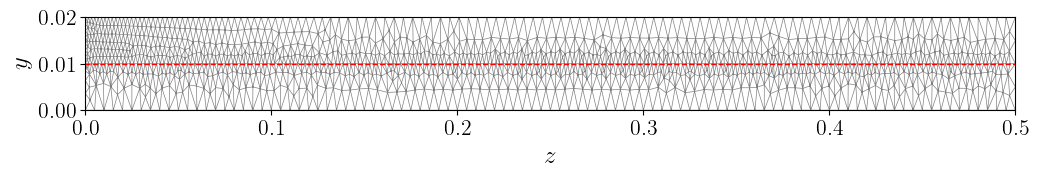

In [89]:
# Visualize the mesh real quick:
plot(mesh)
plt.gca().lines[0].set_linewidth(0.5)
plt.gca().set_aspect(2.5/1)
plt.gca().set_xlim(0, l)
plt.gca().set_xlabel("$z$")
plt.gca().set_ylabel("$y$")
plt.gca().set_ylim(0, h0+b0)
plt.gcf().set_size_inches(12, 6)
plt.plot(np.linspace(0, l, 10), np.ones(10)*(h0+b0)/2,
         linestyle='--', linewidth=1.0, color='red')
plt.show()

In [90]:
# Define subdomains for use in boundary condition definitions:
class Wall_b(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[1] < d_tol))

class Wall_t(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[1] > SOLID_TOP - d_tol))

class Wall_l(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] < d_tol)
                and x[1] > SOLID_BOTTOM - d_tol)

class Wall_r(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] > SOLID_RIGHT - d_tol)
                and x[1] > SOLID_BOTTOM - d_tol)

class Inflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] < d_tol)
                and x[1] < SOLID_BOTTOM + d_tol)

class Outflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] > (OMEGA_W - d_tol))
                and x[1] < SOLID_BOTTOM + d_tol)

class SolidDomainClosure(SubDomain):
    def inside(self, x, on_boundary):
        return (x[1] > SOLID_BOTTOM - d_tol
                and x[1] < SOLID_TOP + d_tol
                and x[0] > SOLID_LEFT - d_tol
                and x[0] < SOLID_RIGHT + d_tol)

class SolidDomainInterior(SubDomain):
    def inside(self, x, on_boundary):
        return (x[0] > SOLID_LEFT - d_tol
                and x[0] < SOLID_RIGHT + d_tol
                and x[1] < SOLID_TOP + d_tol
                and x[1] > SOLID_BOTTOM + d_tol)

In [91]:
# Markers instead of mshr.domains():
markers = MeshFunction('size_t', mesh, d)
markers.set_all(FLUID_FLAG)                      # default: fluid = 0
SolidDomainClosure().mark(markers, SOLID_FLAG)   # reset: solid = 1

# Facet markers (0 = default):
facet_tags = MeshFunction('size_t', mesh, d-1, 0)

# Mark boundaries with IDs, if you wish:
# BOTTOM, LEFT, RIGHT, TOP = 11, 12, 13, 14
# Wall_b().mark(facet_tags, BOTTOM)
# Wall_l().mark(facet_tags, LEFT)
# Wall_r().mark(facet_tags, RIGHT)
# Wall_t().mark(facet_tags, TOP)
INFLOW, OUTFLOW = 3, 2 
Inflow().mark(facet_tags, INFLOW)
Outflow().mark(facet_tags, OUTFLOW)

# Quadrature-aware exterior measure with facet markers:
dx = dx(metadata={'quadrature_degree': 2}, subdomain_data=markers)
ds = ds(metadata={'quadrature_degree': 2}, subdomain_data=facet_tags)

### Time stepping details

Time stepping details come after setting the everything else, so that we can properly set them for the _given_ problem.

In [92]:
# Fixed physical time step [s] to achieve a given CFL.
CFL            = 10.0
Dt             = Constant(CFL*mesh.hmin()/float(v_c))
# Need to tune this to ensure the ramp is gradual enough;
# if there are too many (dozens) of coupling iters, reduce it.
MAX_DELTA_H    = 2e-3
# Target pressure increment per time step [Pa/step]:
P_RAMP_RATE    = MAX_DELTA_H * float(p_c) / alpha
# No. time steps needed to ramp from 0 to p_sh(0)
N_T_STEPS_RAMP = int(np.ceil(float(p_sh(0)) / P_RAMP_RATE))
# No. time steps to hold at final pressure after ramping:
N_T_STEPS      = 2*N_T_STEPS_RAMP 
# Thus:
RAMP_TIME      = N_T_STEPS_RAMP*float(Dt)
FINAL_TIME     = N_T_STEPS*float(Dt)
N_SKIP         = 5

print(f"p_sh(0) = {float(p_sh(0)):.3g} Pa")
print(f"Target pressure increment per time step: {float(P_RAMP_RATE):.3g} Pa/step")
print(f"Number of time steps: {N_T_STEPS}, Δt: {float(Dt):.3g} s")
print(f"Ramp time: {RAMP_TIME:.3g} s, Final time: {FINAL_TIME:.3g} s")

p_sh(0) = 2e+05 Pa
Target pressure increment per time step: 2.28e+03 Pa/step
Number of time steps: 176, Δt: 0.00356 s
Ramp time: 0.313 s, Final time: 0.627 s


### Boundary conditions

Implementation of the boundary conditions come after setting the everything else, so that we can properly set them for the _given_ problem.

In [93]:
if np.isclose(omega, 0):
    # Ramped-up-to-steady BC:
    p_in  = Expression("p0*(t<tr ? t/tr : 1.0)", 
                       p0=float(p_amp), tr=float(RAMP_TIME), t=0.0, degree=1)

    v_in  = Expression(("x[1]<h0 ? 6*(q0*(t<tr ? t/tr : 1.0)/h0)*(x[1]/h0)*(h0-x[1])/h0 : 0.0", "0.0"), 
                       tr=float(RAMP_TIME), q0=float(q_amp), h0=float(h0), t=0.0, degree=2)
else:
    # Oscillatory flow BCs:
    print(f"Oscillation period: {2*np.pi/omega:.3g} s")
    p_in  = Expression("p0*cos(w*t)", 
                       p0=float(p_amp), w=float(omega), t=0.0, degree=1)
    
    v_in  = Expression(("x[1]<h0 ? 6*(q0/h0)*cos(w*t)*(x[1]/h0)*(h0-x[1])/h0 : 0.0", "0.0"), 
                       q0=float(q_amp), w=float(omega), h0=float(h0), t=0.0, degree=2)

# Variational problem definitions

## Elements and function spaces

In [94]:
# Define function spaces (equal order interpolation):
cell = mesh.ufl_cell()
Ve = VectorElement("CG", cell, 2) # can also be 1 since we have stabilization
Qe = FiniteElement("CG", cell, 1)
VQe = MixedElement((Ve,Qe))

# Mixed function space for velocity and pressure:
W = FunctionSpace(mesh, VQe)

# Function space for mesh displacement field, 
# which will be solved for separately in a 
# quasi-direct scheme:
Vm = VectorElement("CG", cell, 1)
V = FunctionSpace(mesh,Vm)

## Time integration variables

In [95]:
# Mesh motion functions:
uhat = Function(V)
uhat_old = Function(V)
du = TestFunction(V)
vhat = (uhat-uhat_old)/Dt

# Fluid--structure functions:
(dv, dp) = TestFunctions(W)
w = Function(W)
v, p = split(w)
p_mean = Function(W)
w_old = Function(W)
v_old, p_old = split(w_old)
dv_dr = (v - v_old)/Dt
dv_ds = dv_dr # (Only valid in solid)

# This is the displacement field used in the 
# solid formulation; notice that it is NOT 
# in the space V; it is an algebraic object 
# involving the unknown fluid--structure velocity 
# field v.
u = uhat_old + Dt*v

# This will need to be updated to match u, for 
# purposes of setting the boundary condition 
# on the mesh motion subproblem.
u_func = Function(V)

## ALE kinematics (change of variables)

In [96]:
# Follow notation from Bazilevs et al., where y is 
# the coordinate in the reference domain, x is the 
# coordinate in the spatial domain, and X is the 
# coordinate in the material domain.  Note that 
# the built-in differential operators (e.g., grad, 
# div, etc.) and integration measures (e.g., dx, ds, 
# etc.) are w.r.t. the reference configuration, y, 
# which is the mesh that FEniCS sees.  
dX = dx(SOLID_FLAG)
dy = dx
ds_y = ds

grad_y = grad
grad_X = grad # (Only valid in solid)

y = SpatialCoordinate(mesh)
x = y + uhat

det_dxdy = det(grad_y(x))

def grad_x(f):
    return dot(grad_y(f),inv(grad_y(x)))

def div_x(f): # (For vector-valued f)
    return tr(grad_x(f))

def div_x_tens(f): # (For (rank-2) tensor-valued f)
    i,j = indices(2)
    return as_tensor(grad_x(f)[i,j,j],(i,))

# Note:  Trying to define dx = det_dxdy*dy would 
# result in an object of type Form, which could no 
# longer be used as an integration measure.
# Thus, integration over the spatial configuration 
# is done with det_dxdy*dy directly in the fluid 
# formulation.  

## Boundary conditions (simulation)

In [97]:
# BCs for the fluid--structure subproblem:
bc_b_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_b())
bc_l_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_l())
bc_r_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_r())
bc_t_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_t())

# Inlet BC: either flow rate or pressure
if FLOW_OR_PRESSURE == "FLOW":
    bc1_fs = DirichletBC(W.sub(0), v_in, Inflow())
elif FLOW_OR_PRESSURE == "PRESSURE":
    bc1_fs = DirichletBC(W.sub(1), p_in, Inflow())
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

bc2_fs = DirichletBC(W.sub(1), Constant(0.0), SolidDomainInterior())                     

bcs_fs = [bc_b_fs, bc_l_fs, bc_r_fs, bc_t_fs, bc1_fs, bc2_fs]
#bcs_fs = [bc_b_fs, bc1_fs, bc2_fs]

# BCs for the mesh motion subproblem:
#bc_m_wall_b  = DirichletBC(V.sub(1), Constant(0.0), Wall_b())
#bc_m_wall_t  = DirichletBC(V.sub(1), Constant(0.0), Wall_t())
bc_m_wall_b  = DirichletBC(V, Constant(d*(0.0,)), Wall_b())
bc_m_wall_t  = DirichletBC(V, Constant(d*(0.0,)), Wall_t())
# Roller BCs on left & right walls of solid & fluid domain:
# bc_m_wall_l  = DirichletBC(V.sub(0), Constant(0.0), Wall_l())
# bc_m_wall_r  = DirichletBC(V.sub(0), Constant(0.0), Wall_r())
# bc_m_inflow  = DirichletBC(V.sub(0), Constant(0.0), Inflow())
# bc_m_outflow = DirichletBC(V.sub(0), Constant(0.0), Outflow())
# "Full" Dirichlet BCs on left & right walls of solid & fluid domain:
bc_m_wall_l  = DirichletBC(V, Constant(d*(0.0,)), Wall_l())
bc_m_wall_r  = DirichletBC(V, Constant(d*(0.0,)), Wall_r())
bc_m_inflow  = DirichletBC(V, Constant(d*(0.0,)), Inflow())
bc_m_outflow = DirichletBC(V, Constant(d*(0.0,)), Outflow())

bc_m_struct  = DirichletBC(V, u_func, SolidDomainClosure())

bcs_m        = [bc_m_struct, 
                bc_m_wall_b, bc_m_wall_l, bc_m_wall_r, bc_m_wall_t, 
                bc_m_inflow, bc_m_outflow]

## Mesh motion subproblem

In [98]:
# Residual for mesh, which satisfies a fictitious elastic problem:
F_m = grad_y(uhat) + I
E_m = 0.5*(F_m.T*F_m - I)
m_jac_stiff_pow = Constant(3.0)

# Artificially stiffen the mesh where it is getting crushed:
K_m    = Constant(1.0)/pow(det(F_m),m_jac_stiff_pow)
mu_m   = Constant(1.0)/pow(det(F_m),m_jac_stiff_pow)
S_m    = K_m*tr(E_m)*I + 2.0*mu_m*(E_m - tr(E_m)*I/3.0)
res_m  = (inner(F_m*S_m,grad_y(du)))*dy
Dres_m = derivative(res_m, uhat)

## Solid subproblem


In [ ]:
# Kinematics:
F = grad_X(u) + I

if ELASTICITY_MODEL == "STVK":
    E = 0.5*(F.T*F - I)
    S = K*tr(E)*I + 2.0*mu_s*(E - tr(E)*I/3.0)
elif ELASTICITY_MODEL == "NEOH":
    # Neo-Hookean, W = (mu_s/2)*(I1 - 3) - mu_s*ln(J) + (lam/2)*(ln(J))^2
    # Isochoric-volumetric Neo-Hookean (preferred for nu close to 0.5)
    J_s   = det(F)
    C     = F.T * F
    # Plane strain: F_{33}=1 -> C_{33}=1 -> I1_3D = tr(C_{2D}) + 1
    # WARNING: this +1 is wrong for plane stress or axisymmetry!
    I1    = tr(C) + Constant(1.0)
    Cinv  = inv(C)
    # 2nd Piola-Kirchhoff stress:
    S_iso = mu_s * J_s**Constant(-2.0/3.0) * (I - Constant(1.0/3.0)*I1*Cinv)
    S_vol = K * (J_s - Constant(1.0)) * J_s * Cinv
    S     = S_iso + S_vol
else:
    raise ValueError("Unknown value of ELASTICITY_MODEL!")

# 1st Piola-Kirchhoff stress, P=F*S, for use in the momentum eq.
P = F * S

# Momentum equation in solid:
f_s = Constant(d*(0,))         # body force in solid
f_s += -cd*v                   # to implement damping
res_s = rho_s0*inner(dv_ds - f_s,dv)*dX + inner(P,grad_X(dv))*dX

## Fluid subproblem


In [100]:
# Shear rate helper function:
def gamma_dot(v):
    E_f = sym(grad_x(v))
    return sqrt(2.0*inner(E_f, E_f) + DOLFIN_EPS)

# Effective viscosity (Carreau model):
def mu_eff(v):
    return eta_f_inf + (eta_f_0 - eta_f_inf) \
           * (1.0 + (lam_r*gamma_dot(v))**2.0)**((n-1.0)/2.0)

# Cauchy stress of the fluid:
sigma_f = 2.0*mu_eff(v)*sym(grad_x(v)) - p*I

# Convective term of the fluid:
v_adv    = v - vhat
DvDt     = dv_dr + dot(grad_x(v),v_adv)
resGal_f = (rho_f*dot(DvDt,dv) + inner(sigma_f,grad_x(dv))
            + dp*div_x(v))*det_dxdy*dy(FLUID_FLAG)

# Stabilization:

# Deformed mesh size tensor in the spatial configuration:
J_m = Jacobian(mesh)                
dxi_dy = inv(J_m)
dxi_dx = dxi_dy*inv(grad_y(x))
G = (dxi_dx.T)*dxi_dx

# SUPG/PSPG:
resStrong_f = rho_f*DvDt - div_x_tens(sigma_f)
Cinv = Constant(1.0)
tau_M = 1.0/sqrt(((2*rho_f/Dt)**2) 
                 + inner(rho_f*v_adv,G*(rho_f*v_adv))
                 + Cinv*(eta_f_0**2)*inner(G,G))
resSUPG_f = inner(tau_M*resStrong_f,
                  rho_f*dot(grad_x(dv),v_adv)
                  + grad_x(dp))*det_dxdy*dy(FLUID_FLAG)
# LSIC/grad-div:
tau_C = 1.0/(tr(G)*tau_M + DOLFIN_EPS)
resLSIC_f = tau_C*div_x(v)*div_x(dv)*det_dxdy*dy(FLUID_FLAG)

# Stable Neumann BC term, assuming advective 
# form of material time derivative term and transforming
# normal and area element by Nanson's formula (on deforming mesh):
dsx_dsy_n_x = det_dxdy*inv(grad_y(x).T)*n_y
v_adv_minus = Min(dot(v_adv,dsx_dsy_n_x),Constant(0))
gm = Constant(1.0) # or 0.5
resOutflow_f = -gm*dot(rho_f*v_adv_minus*dv,v)*ds_y(OUTFLOW)
resInflow_f = -gm*dot(rho_f*v_adv_minus*dv,v)*ds_y(INFLOW)

# For inlet pressure BCs
if FLOW_OR_PRESSURE == "FLOW":
    Consistency_term = 0
elif FLOW_OR_PRESSURE == "PRESSURE":
    traction = -p_in*n_y
    Consistency_term = -(inner(det_dxdy*inv(grad_y(x).T)*traction,dv))*ds_y(INFLOW)
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

# Total fluid residual:
res_f = resGal_f
# and stabilization terms as needed:
if SUPG:  
    res_f += resSUPG_f
if LSIC:
    res_f += resLSIC_f
if BACKFLOW_STAB:
    res_f += resOutflow_f
# Add consistent traction at inlet to enforce pressure as Neumann BC:
if FLOW_OR_PRESSURE == "PRESSURE":
    res_f += Consistency_term

## Nonlinear solver(s) for the variational problems

In [101]:
# Nonlinear solver parameters; set relative tolerances 
# for subproblems tighter than tolerance for coupled problem, 
# to prevent stagnation.
REL_TOL_FSM   = 1e-4 #5
ABS_TOL_FSM   = 1e-8 #10
REL_TOL_FS    = REL_TOL_M = REL_TOL_FSM*1e-1
ABS_TOL_FS    = ABS_TOL_M = ABS_TOL_FSM*1e-1
MAX_ITERS_FSM = 100
MAX_ITERS_M   = 100
MAX_ITERS_FS  = 100
OMG_RELAX_FSM = 0.5

# Set up nonlinear problem for mesh motion:
problem_m = NonlinearVariationalProblem(res_m, uhat, bcs_m, Dres_m)
solver_m  = NonlinearVariationalSolver(problem_m)
solver_m.parameters['newton_solver']\
                   ['maximum_iterations'] = MAX_ITERS_M
solver_m.parameters['newton_solver']\
                   ['relative_tolerance'] = REL_TOL_M
solver_m.parameters['newton_solver']\
                   ['absolute_tolerance'] = ABS_TOL_M

# Residual of fluid--structure coupled problem:
res_fs = res_f + res_s 
Dres_fs = derivative(res_fs, w)

# Create variational problem and solver for 
# the fluid--structure problem:
problem_fs = NonlinearVariationalProblem(res_fs, w, bcs_fs, Dres_fs)
solver_fs  = NonlinearVariationalSolver(problem_fs)
solver_fs.parameters['newton_solver']\
                    ['maximum_iterations'] = MAX_ITERS_FS
solver_fs.parameters['newton_solver']\
                    ['relative_tolerance'] = REL_TOL_FS
solver_fs.parameters['newton_solver']\
                    ['absolute_tolerance'] = ABS_TOL_FS

# Time stepping

## Initial conditions

In [102]:
# # Interpolate into subspaces
# V_sub = W.sub(0).collapse()
# Q_sub = W.sub(1).collapse()

# v_n_init = interpolate(v_rigid, V_sub)
# p_n_init = interpolate(p_rigid, Q_sub)

# # Assign to mixed function
# assign(w_old, [v_n_init, p_n_init])

## Time stepping loop

In [103]:
# Create files for storing solution:
vfile = File(DataFolder+"velocity.pvd")
pfile = File(DataFolder+"pressure.pvd")
mfile = File(DataFolder+"mesh.pvd")

# Save initial condition to file:
# v_n_init.rename("v","v")
# p_n_init.rename("p","p")
# uhat.rename("u","u")
# vfile << v_n_init
# pfile << p_n_init
# mfile << uhat

# Prepare to store time-dependent post-processed quantities:
flow_rate_save = []
time_array = []

# Initialize time and step counter:
t = 0
count = 0

#while t <= FINAL_TIME:
for count in range(N_T_STEPS):     # more robust than t <= FINAL_TIME

    print(80*"=", flush=True)
    print(f"  Time step {count+1} of {N_T_STEPS}", 
          f"from t = {t:.3e} with Dt = {float(Dt):.3g}", flush=True)
    print(80*"=", flush=True)

    if FLOW_OR_PRESSURE == "FLOW":
        v_in.t = t
    elif FLOW_OR_PRESSURE == "PRESSURE":
        p_in.t = t
    else:
        raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

    # Reset Aitken parameters for each time step:
    r_prev = None
    OMG_RELAX_FSM = 0.5

    # Quasi-direct coupling loop:
    for i in range(0,MAX_ITERS_FSM):
        res_fs_vec = assemble(res_fs)
        for bc in bcs_fs:
            bc.apply(res_fs_vec,w.vector())
        res_norm = norm(res_fs_vec)
        if i == 0:
            res_norm0 = res_norm
        res_rel = res_norm/max(res_norm0, ABS_TOL_FSM)

        print(80*"*", flush=True)
        print(f"  Coupling iteration {i+1} ,",
              f"Absolute residual = {res_norm:.6e} ,",
              f"Relative residual = {res_rel:.6e}", flush=True)
        print(80*"*", flush=True)

        abs_ok = (res_norm < ABS_TOL_FSM)
        rel_ok = (res_rel < REL_TOL_FSM)
        if abs_ok or rel_ok:
            reason = "abs+rel" if (abs_ok and rel_ok) else ("abs" if abs_ok else "rel")
            print("  >>>>> Met", reason.upper(), "tolerance stopping criterion.", flush=True)
            break
        
        # Solve F-S problem:
        solver_fs.solve()
        u_proj = project(u,V)

        # Aitken's Δ² method: update omega dynamically
        r = u_proj.vector()[:] - u_func.vector()[:] 
        if r_prev is not None:
            dr = r - r_prev
            denom = np.dot(dr, dr)
            if denom > 1e-14 and denom > 1e-6 * np.dot(r, r):
                OMG_RELAX_FSM = -OMG_RELAX_FSM * np.dot(r_prev, dr) / denom
        r_prev = r.copy()
        # Now, apply relaxation:
        u_func.vector()[:] += OMG_RELAX_FSM * r

        # Run mesh update after relaxation:
        solver_m.solve()

    # Final mesh sync: enforce kinematic constraint exactly (no under-relaxation)
    # so that uhat_old at the next time step is consistent with the converged w.
    u_proj = project(u, V)
    u_func.assign(u_proj)
    solver_m.solve()

    # Post-process and advance time.
    (v, p) = w.split()

    if count % N_SKIP == 0:
        v.rename("v","v")
        p.rename("p","p")
        uhat.rename("u","u")
        vfile << v
        pfile << p
        mfile << uhat

    uhat_old.assign(uhat)
    w_old.assign(w)
    count += 1
    t += float(Dt)

    q_in_r = assemble(dot(v,n_y)*ds_y(INFLOW))
    q_in_d = assemble(dot(v,dsx_dsy_n_x)*ds_y(INFLOW))
    q_out_r = assemble(dot(v,n_y)*ds_y(OUTFLOW))
    q_out_d = assemble(dot(v,dsx_dsy_n_x)*ds_y(OUTFLOW))
    flow_rate_save.append([q_in_r,q_in_d,q_out_r,q_out_d])
    time_array.append(t)

  Time step 1 of 176 from t = 0.000e+00 with Dt = 0.00356
********************************************************************************
  Coupling iteration 1 , Absolute residual = 0.000000e+00 , Relative residual = 0.000000e+00
********************************************************************************
  >>>>> Met ABS+REL tolerance stopping criterion.
  Solving nonlinear variational problem.
    Newton iteration 0: r (abs) = 0.000e+00 (tol = 1.000e-09) r (rel) = nan (tol = 1.000e-05)
    Newton solver finished in 0 iterations and 0 linear solver iterations.
  Time step 2 of 176 from t = 3.562e-03 with Dt = 0.00356
********************************************************************************
  Coupling iteration 1 , Absolute residual = 5.081980e+03 , Relative residual = 1.000000e+00
********************************************************************************
  Solving nonlinear variational problem.
    Newton iteration 0: r (abs) = 1.558e+04 (tol = 1.000e-09) r (rel) = 1

# Visualization and post-processing

Some meshing preliminaries. 

We make horizontal scales dimensionless by dividing by $\ell$, and vertical scales dimensionless by dividing by $h_0+b_0$.

In [104]:
# Extract coordinates and displacement values:
coordinates = mesh.coordinates()
cells = mesh.cells()
dim = mesh.geometry().dim()
num_vertices = len(coordinates)

# Create triangulation and plot:
x_coords = coordinates[:, 0]/l
y_coords = coordinates[:, 1]/(h0+b0)
triang = tri.Triangulation(x_coords, y_coords, cells)

# Get displacement components by projecting algebraic u onto V space:
u_fn = project(u, V)
ux, uy = u_fn.split(deepcopy=True)

## Diagnostics

In [105]:
time_array = np.array(time_array)
saved_qs = np.array(flow_rate_save)

In [106]:
# Mesh Jacobian checks:
J_mesh = project(det(grad_y(y+u)), FunctionSpace(mesh, "DG", 0))
J_vals = J_mesh.vector()[:]

# # Mass conservation on the fluid boundaries:
# Q_in = assemble(dot(v, dsx_dsy_n_x) * ds(INFLOW))
# Q_out = assemble(dot(v, dsx_dsy_n_x) * ds(OUTFLOW))
# Q_wall = assemble(dot(v, dsx_dsy_n_x) * ds(NS_WALLS))
# Q_walls = assemble(dot(v, n_y) * ds(NS_WALLS))
# Q_FS = assemble(dot(v('-'), n_y('-')) * dS(INTERFACE))
# sum_Q = float(Q_in + Q_out + Q_walls + Q_FS)

# Some div v diagnostics:
mass_residual = assemble(det_dxdy * div_x(v) * dx(FLUID_FLAG))

div_L2 = assemble(div_x(v)**2 * det_dxdy * dx(FLUID_FLAG))**0.5
fluid_volume = assemble(det_dxdy * dx(FLUID_FLAG))
div_rms = div_L2 / sqrt(fluid_volume)

V0 = FunctionSpace(mesh, "DG", 0)
divv = project(div_x(v), V0)

# Pressure diagnostics:
x_test = np.array([0.0, l/3, l/2, 2*l/3, l])
p_computed = [p(xi, h0/2) for xi in x_test]
p_theory = [p_sh(xi, h0/2) for xi in x_test]

print("======================== DIAGNOSTICS ========================")
print(f"det(F) min: {J_vals.min():.6f}            |  "
      f"det(F) max: {J_vals.max():.6f}")
print(f"Number of inverted elements: {sum(J_vals < 0)}  |  "
      f"Number near-inverted (J < 0.3): {sum(J_vals < 0.3)}")

# Where is the problem?
if J_vals.min() < 0.3:
    bad_cells = np.where(J_vals < 0.3)[0]
    print(f"Problematic cells: {bad_cells[:10]}")  # First 10

    # Get coordinates of bad cells
    V0 = FunctionSpace(mesh, "DG", 0)
    coords = V0.tabulate_dof_coordinates()
    for cell_id in bad_cells[:5]:
        print(
            f"  Cell {cell_id} at ({coords[cell_id, 0]:.4f}, {coords[cell_id, 1]:.4f})")

print()

print(f"Q_in + Q_out : {saved_qs[-1,1] + saved_qs[-1,3]:.6e} (target: < 1e-6 ?)")
print(f"∫ div(v) dΩ  : {abs(mass_residual):.6e} (target: < 1e-8 ?)")


# Interpolate the inlet profile to the velocity space restricted on the inflow
#v_in_V = interpolate(v_in, W.sub(0).collapse())

# Compute L2 mismatch *on the inflow boundary* (via boundary integral of full vector)
if FLOW_OR_PRESSURE == "FLOW":
    mismatch_vec = assemble(inner(v - v_in_V, v - v_in_V) * ds(INFLOW))
    print()
    print("inlet velocity profile mismatch (only small if imposing v BC)")
    print(f"||v - v_in||_L2(Γ_in) = {mismatch_vec**0.5:.6e}")

print()
print(f"p_inlet  = {p_rigid(0, h0):.4f} Pa (rigid)")
print(f"p_inlet  = {p_theory[0]:.4f} Pa (soft hydraulics (plaw))")
print(f"p_inlet  = {p_computed[0]:.4f} Pa (sim)")
print()
print("Pressure (p/p_c) comparisons at interface y=h_0:")
print(f"  x=0:    sim={p_computed[0]/float(p_c):5g},",
      f"soft hydraulics (plaw)={p_theory[0]/float(p_c):5g},",
      f"% err={100.0*abs(p_computed[0]-p_theory[0])/abs(p_theory[0]):.2f}%")
print(f"  x=l/3:  sim={p_computed[1]/float(p_c):5g},",
      f"soft hydraulics (plaw)={p_theory[1]/float(p_c):5g},",
      f"% err={100.0*abs(p_computed[1]-p_theory[1])/abs(p_theory[1]):.2f}%")
print(f"  x=l/2:  sim={p_computed[2]/float(p_c):5g},",
      f"soft hydraulics (plaw)={p_theory[2]/float(p_c):5g},",
      f"% err={100.0*abs(p_computed[2]-p_theory[2])/abs(p_theory[2]):.2f}%")
print(f"  x=2l/3: sim={p_computed[3]/float(p_c):5g},",
      f"soft hydraulics (plaw)={p_theory[3]/float(p_c):5g},",
      f"% err={100.0*abs(p_computed[3]-p_theory[3])/abs(p_theory[3]):.2f}%")
# print(f"  x=l:    sim={p_computed[4]/float(p_c):5g}, theory={p_theory[4]/float(p_c):5g}")
print("=============================================================")

======================== DIAGNOSTICS ========================
det(F) min: 0.827572            |  det(F) max: 1.682829
Number of inverted elements: 0  |  Number near-inverted (J < 0.3): 0

Q_in + Q_out : 2.830403e-05 (target: < 1e-6 ?)
∫ div(v) dΩ  : 4.006721e-05 (target: < 1e-8 ?)

p_inlet  = 200000.0000 Pa (rigid)
p_inlet  = 200000.0000 Pa (soft hydraulics (plaw))
p_inlet  = 200000.0000 Pa (sim)

Pressure (p/p_c) comparisons at interface y=h_0:
  x=0:    sim=    1, soft hydraulics (plaw)=    1, % err=0.00%
  x=l/3:  sim=0.715098, soft hydraulics (plaw)=0.716752, % err=0.23%
  x=l/2:  sim=0.558054, soft hydraulics (plaw)=0.559779, % err=0.31%
  x=2l/3: sim=0.388143, soft hydraulics (plaw)=0.389999, % err=0.48%


## Inlet/outlet flow rates

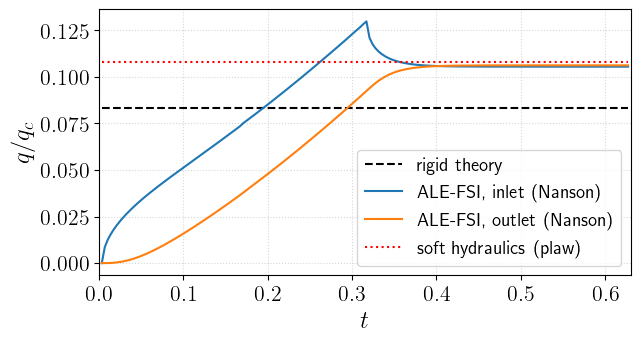

In [107]:
# Create plot:
fig, ax = plt.subplots()
ax.plot(time_array, float(q_rigid/q_c)*np.ones(len(time_array)), 
        label='rigid theory', linestyle='dashed', color='black')

# Note: signed flow rate is negative at inlet and positive at outlet
# ax.plot(time_array, -saved_qs[:,0]/float(q_c), 
#         label=r'ALE-FSI, initial/rigid inlet', color='blue')
ax.plot(time_array, -saved_qs[:,1]/float(q_c), 
        label=r"ALE-FSI, inlet (Nanson)")
# ax.plot(time_array, saved_qs[:,2]/float(q_c), 
#         label=r'ALE-FSI, initial/rigid outlet', color='cornflowerblue')
ax.plot(time_array, saved_qs[:,3]/float(q_c), 
        label=r"ALE-FSI, outlet (Nanson)")

ax.plot(time_array, float(q_sh/q_c)*np.ones(len(time_array)), 
        label='soft hydraulics (plaw)', linestyle='dotted', color='red')

ax.set_xlabel('$t$')
ax.set_ylabel('$q/q_c$')
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, np.round(time_array[-1],2))
#ax.set_ylim(0, float(q_amp))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.tight_layout()
plt.show()

## Height-averaged axial pressure distribution

In [108]:
# Sampling parameters:
num_x_samples = 50
num_y_samples = 100
x_vals = np.linspace(0.0, l, num_x_samples)
y_line = np.linspace(0.0, h0, num_y_samples)

# Cross-sectional averages via line integrals (trapz along y at fixed x).
# More accurate than strip-indicator approach: no area-averaging artefacts,
# no DG0/CG1 indicator mismatch, proper 1/h0 normalisation.

# Sampling d, dp/dx, d2p/dx2:
avg_p = np.array([
    np.trapezoid([p(float(xi), float(yj)) for yj in y_line], y_line) / h0
    for xi in x_vals
])

# If needed, d/dx and d2/dx2 axial derivatives 
# via central differences (O(Δx²) interior):
# avg_dpdx   = np.gradient(avg_p,    x_vals)
# avg_d2pdx2 = np.gradient(avg_dpdx, x_vals)

# Rigid-channel and soft-hydraulic reference pressures:
pressure_rigid = np.array([p_rigid(float(xi), 0.0) for xi in x_vals])
pressure_sh    = np.array([p_sh(float(xi),    0.0) for xi in x_vals])

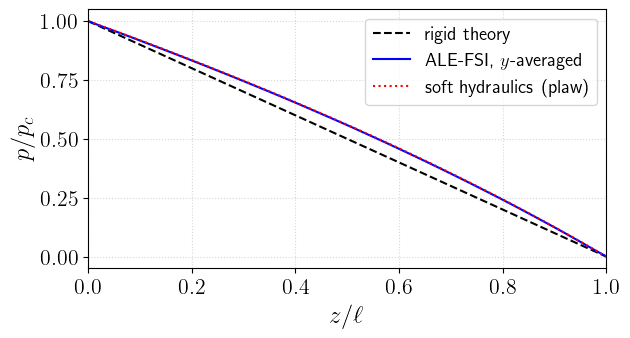

In [109]:
# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, pressure_rigid/float(p_c), 
        label='rigid theory', linestyle='dashed', color='black')
ax.plot(x_vals/l, avg_p/float(p_c), 
        label='ALE-FSI, $y$-averaged', color='blue')
ax.plot(x_vals/l, pressure_sh/float(p_c), 
        label='soft hydraulics (plaw)', linestyle='dotted', color='red')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel('$p/p_c$')
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.show()


## Fluid&ndash;solid interface displacement and pressure

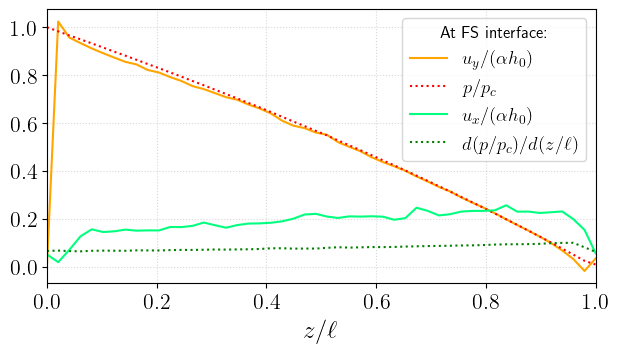

In [110]:
# Create points along the fluid-solid interface:
fs_line_points = [(x, h0) for x in x_vals]

# Evaluate the vertical displacement and pressure at each point:
uy_fs_values = np.array([uy(point) for point in fs_line_points])
ux_fs_values = np.array([ux(point) for point in fs_line_points])
p_fs_values  = np.array([p(point) for point in fs_line_points])
# d/dx and d2/dx2 axial derivatives via central differences, O(Δx²):
dpdx_fs      = np.gradient(p_fs_values, x_vals)
d2pdx2_fs    = np.gradient(dpdx_fs, x_vals)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, uy_fs_values/float(alpha*h0),
        label=r'$u_y/(\alpha h_0)$', color='orange')
ax.plot(x_vals/l, p_fs_values/float(p_c), 
        label='$p/p_c$', color='red', linestyle='dotted')
ax.plot(x_vals/l, ux_fs_values/float(alpha*h0),
        label=r'$u_x/(\alpha h_0)$', color='springgreen')
ax.plot(x_vals/l, -vartheta*dpdx_fs/(float(p_c)/l), 
        label=r'$d(p/p_c)/d(z/\ell)$', color='green', linestyle='dotted')

ax.set_xlabel(r'$z/\ell$')
#ax.set_ylabel()
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend(title="At FS interface:", title_fontsize='large')

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.show()    

## Pressure contours

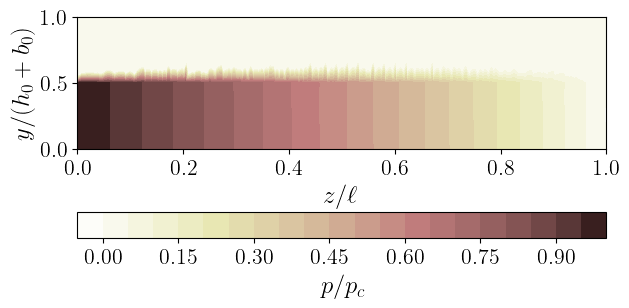

In [111]:
# Get pressure values at vertices:
pressure_values = p.compute_vertex_values(mesh)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(triang, pressure_values/float(p_c), 
                         levels=20, cmap='pink_r')
fig.colorbar(contour, label='$p/p_c$', orientation='horizontal')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()

## Fluid velocity magnitude contours

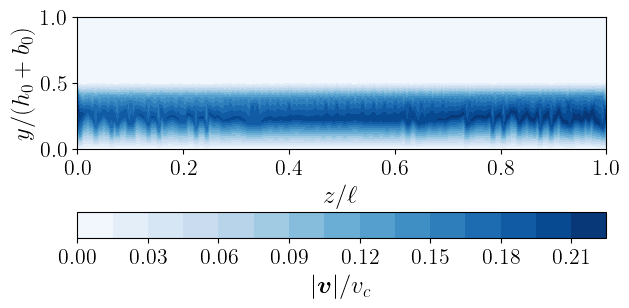

In [112]:
# Get velocity values at vertices:
vx, vy = v.split()
vx_values = vx.compute_vertex_values(mesh)
vy_values = vx.compute_vertex_values(mesh)

# Compute magnitude:
magnitude = np.sqrt(vx_values**2 + vy_values**2)

# Create plot:
fig, ax = plt.subplots()
contour = ax.tricontourf(triang, magnitude/float(v_c), 
                         levels=20, cmap='Blues')
cb = fig.colorbar(contour, orientation='horizontal')
if params['text.usetex']:
    cb.set_label(r'$|\bm{v}|/v_c$')
else:
    cb.set_label(r'$|\vec{v}|/v_c$')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.tight_layout()
plt.show()

## Displacement magnitude contours

We will mask all $y/h_0 < h_0/(h_0+b_0)$ to show only the displacement fiend in the solid. There is mesh displacement in the fluid domain but we do not consider that to be "physical."

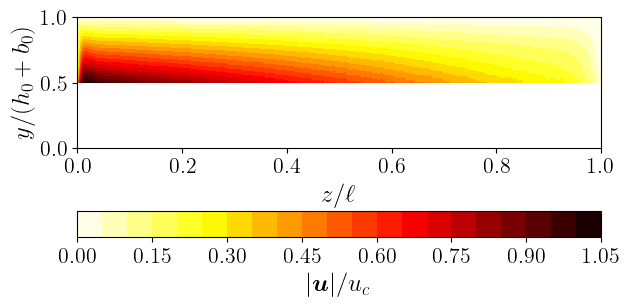

In [113]:
# Get displacement values at vertices:
ux_values = ux.compute_vertex_values(mesh)
uy_values = uy.compute_vertex_values(mesh)

# Compute magnitude:
magnitude = np.sqrt(ux_values**2 + uy_values**2)
# Mask off fluid domain, need to deep copy the triang:
masked_triang =  tri.Triangulation(x_coords.copy(), 
                                   y_coords.copy(), 
                                   cells.copy())
masked_triang.set_mask(
    np.mean(y_coords[masked_triang.triangles], axis=1) < h0/(h0+b0))

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(masked_triang, magnitude/float(alpha*h0), 
                         levels=20, cmap='hot_r')

cb = fig.colorbar(contour, orientation='horizontal')
if params['text.usetex']:
    cb.set_label(r'$|\bm{u}|/u_c$')
else:
    cb.set_label(r'$|\vec{u}|/u_c$')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()